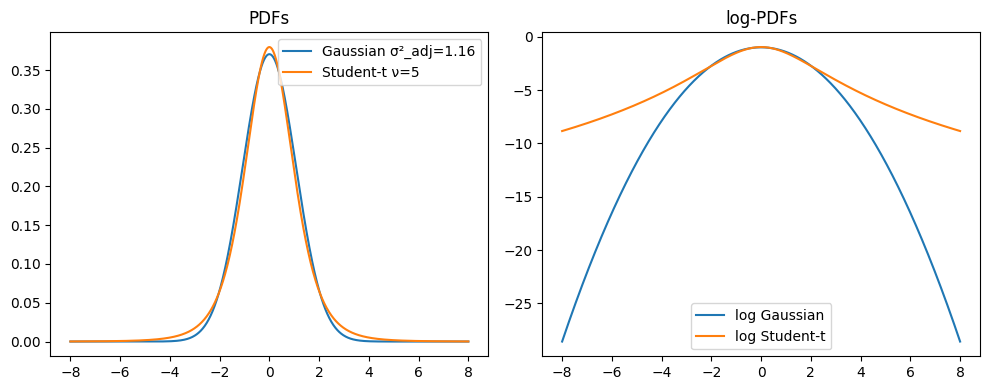

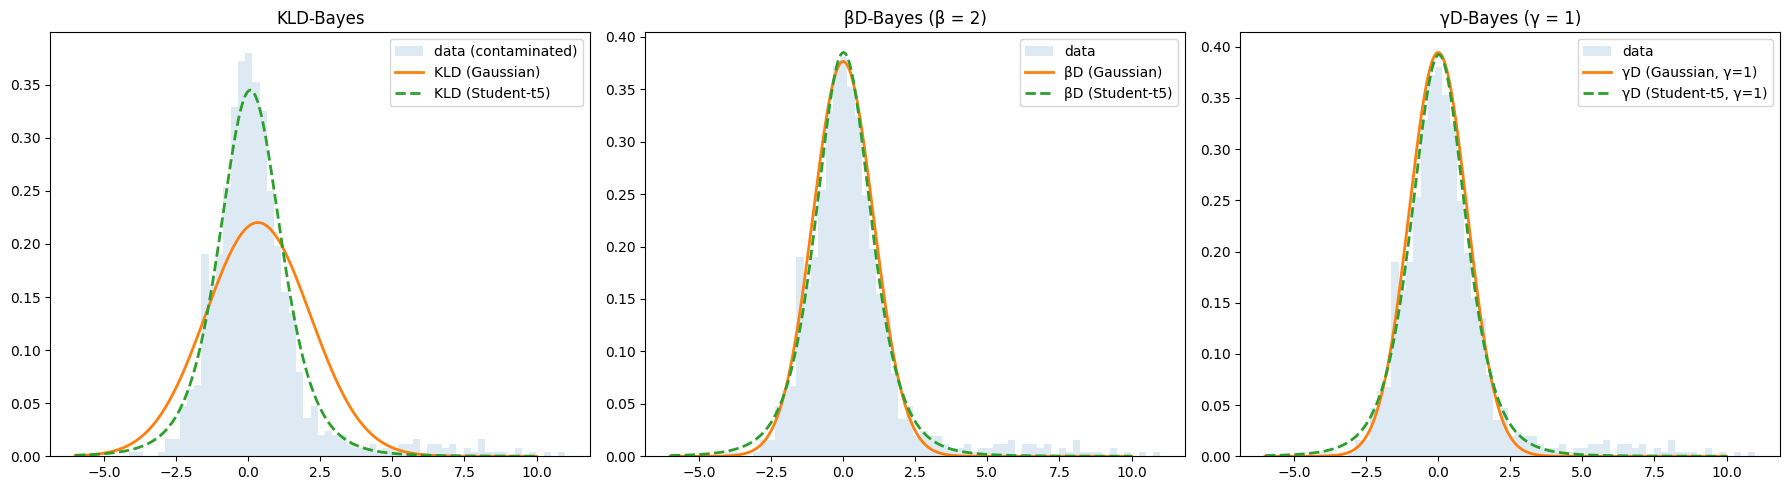

In [19]:
import numpy as np
import scipy.stats as st
import scipy.optimize as opt
import matplotlib.pyplot as plt

# Random generator for reproducibility
rng = np.random.default_rng(42)

# -----------------------------
# 0) Helpers: densities & priors
# -----------------------------
def normal_pdf(y, mu, sig2_adj):
    """Gaussian PDF with variance adjusted by sig2_adj"""
    return st.norm.pdf(y, loc=mu, scale=np.sqrt(sig2_adj))

def t_pdf(y, mu, sig2, nu=5):
    """Student-t PDF with df=nu and variance parameter sig2"""
    return st.t.pdf((y-mu)/np.sqrt(sig2), df=nu) / np.sqrt(sig2)

def log_ig(sig2, a0, b0):
    """Inverse-gamma prior log-density for sigma^2"""
    return st.invgamma(a=a0, scale=b0).logpdf(sig2)

def log_prior(mu, sig2, mu0=0.0, v0=10.0, a0=0.01, b0=0.01):
    """Joint prior = Normal(mu0, v0*sig2) * IG(a0,b0)"""
    return st.norm.logpdf(mu, loc=mu0, scale=np.sqrt(v0*sig2)) + log_ig(sig2, a0, b0)


# -----------------------------
# β-divergence loss
# -----------------------------
def beta_loss_normal(y, mu, sig2, beta, sig2_adj=1.16):
    """
    β-divergence loss for Gaussian likelihood.
    Has closed-form integral term.
    """
    s2 = sig2 * sig2_adj
    f_y = st.norm.pdf(y, loc=mu, scale=np.sqrt(s2))
    term1 = -(f_y**(beta-1))/(beta-1)
    # Closed form integral of f^β
    integral = (2*np.pi*s2)**(-(beta-1)/2) * (beta)**(-0.5)
    term2 = integral / beta
    return term1 + term2

def beta_loss_student(y, mu, sig2, beta, nu=5):
    """
    β-divergence loss for Student-t likelihood.
    Integral term approximated numerically over a grid.
    """
    scale = np.sqrt(sig2)
    f_y = st.t.pdf((y-mu)/scale, df=nu) / scale
    term1 = -(f_y**(beta-1))/(beta-1)
    # Numerical integration over ±12*scale
    z = np.linspace(mu-12*scale, mu+12*scale, 4000)
    f_z = st.t.pdf((z-mu)/scale, df=nu) / scale
    integral = np.trapezoid(f_z**beta, z)
    term2 = integral / beta
    return term1 + term2


# -----------------------------
# 1) Simulate contamination data
# -----------------------------
n = 1000
mix = rng.uniform(size=n) < 0.9
y = np.empty(n)
y[mix]  = rng.normal(0.0, 1.0, size=mix.sum())   # 90% N(0,1)
y[~mix] = rng.normal(5.0, 3.0, size=(~mix).sum()) # 10% N(5, 3^2)


# -----------------------------
# 2) Top row: pdf & log-pdf
# -----------------------------
grid = np.linspace(-8, 8, 1000)
f_pdf = normal_pdf(grid, mu=0.0, sig2_adj=1.16)  # Gaussian approx
h_pdf = t_pdf(grid, mu=0.0, sig2=1.0, nu=5)      # Student-t true

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(grid, f_pdf, label='Gaussian σ²_adj=1.16')
plt.plot(grid, h_pdf, label='Student-t ν=5')
plt.title('PDFs'); plt.legend()

plt.subplot(1,2,2)
eps = 1e-300
plt.plot(grid, np.log(f_pdf+eps), label='log Gaussian')
plt.plot(grid, np.log(h_pdf+eps), label='log Student-t')
plt.title('log-PDFs'); plt.legend()
plt.tight_layout(); plt.show()


# -----------------------------
# 3) KLD-Bayes (Gaussian model)
# -----------------------------
def conjugate_posterior_params(y, mu0=0, v0=10, a0=0.01, b0=0.01):
    """Analytic Normal-Inverse-Gamma posterior parameters"""
    n = len(y)
    ybar = y.mean()
    s2 = ((y - ybar)**2).sum()
    vn = v0 + n
    mun = (v0*mu0 + n*ybar)/vn
    an  = a0 + n/2
    bn  = b0 + 0.5*(s2 + (v0*n/(v0+n))*(ybar-mu0)**2)
    return mun, vn, an, bn

mun, vn, an, bn = conjugate_posterior_params(y)

def kld_posterior_predictive_pdf(z):
    """Posterior predictive under Gaussian model (conjugate)"""
    df = 2*an
    scale = np.sqrt(bn/an * (1.0 + 1.0/vn))
    return st.t.pdf((z-mun)/scale, df=df) / scale


# -----------------------------
# 3b) KLD-Bayes (Student-t model)
# -----------------------------
def neg_log_post_kld(theta, y, nu=5):
    """Negative log-posterior under Student-t likelihood (for KLD)"""
    mu, log_sig2 = theta
    sig2 = np.exp(log_sig2)
    f_y = t_pdf(y, mu, sig2, nu=nu)
    ll = np.sum(np.log(f_y + 1e-12))
    lp = log_prior(mu, sig2)
    return -(ll + lp)

def laplace_map_kld(y, nu=5):
    """Laplace approximation for Student-t KLD posterior"""
    mu0 = np.mean(y)
    sig20 = np.var(y, ddof=1)
    x0 = np.array([mu0, np.log(sig20 if sig20>1e-6 else 1.0)])
    res = opt.minimize(lambda th: neg_log_post_kld(th, y, nu), x0, method='BFGS')
    th_map = res.x
    H = res.hess_inv
    return th_map, H

# Fit Laplace approx for Student-t model
th_map_kld_t, cov_kld_t = laplace_map_kld(y, nu=5)

def sample_from_laplace(th_map, cov, ns=4000, rng=rng):
    """Sample parameters from Gaussian approx posterior"""
    return rng.multivariate_normal(th_map, cov, size=ns)

# Parameter samples for Student-t KLD
th_samps_kld_t = sample_from_laplace(th_map_kld_t, cov_kld_t)

def predictive_from_samples(zgrid, th_samps, use_student=False):
    """Monte Carlo predictive density given parameter samples"""
    vals = np.zeros_like(zgrid)
    for mu, log_sig2 in th_samps:
        sig2 = np.exp(log_sig2)
        if use_student:
            vals += t_pdf(zgrid, mu, sig2, nu=5)
        else:
            vals += normal_pdf(zgrid, mu, sig2*1.16)
    return vals / len(th_samps)

# Student-t predictive under KLD
pred_kld_T = predictive_from_samples(grid, th_samps_kld_t, use_student=True)


# -----------------------------
# 4) βD-Bayes (β=1.22)
# -----------------------------
beta = 2

def neg_log_post_beta(theta, y, use_student=False):
    """Negative log-posterior under β-divergence"""
    mu, log_sig2 = theta
    sig2 = np.exp(log_sig2)
    if use_student:
        loss = beta_loss_student(y, mu, sig2, beta).sum()
    else:
        loss = beta_loss_normal(y, mu, sig2, beta, sig2_adj=1.16).sum()
    lp = log_prior(mu, sig2)
    return loss - lp

def laplace_map_beta(y, use_student=False):
    """Laplace approx for βD-Bayes posterior"""
    mu0 = np.mean(y)
    sig20 = np.var(y, ddof=1)
    x0 = np.array([mu0, np.log(sig20 if sig20>1e-6 else 1.0)])
    res = opt.minimize(lambda th: neg_log_post_beta(th, y, use_student), x0, method='BFGS')
    th_map = res.x
    H = res.hess_inv
    return th_map, H

# Fit Laplace for Gaussian and Student-t βD
th_map_g, cov_g = laplace_map_beta(y, use_student=False)
th_map_t, cov_t = laplace_map_beta(y, use_student=True)

# Parameter samples
th_samps_g = sample_from_laplace(th_map_g, cov_g)
th_samps_t = sample_from_laplace(th_map_t, cov_t)





# =============================
# 5b) γD-Bayes (γ-likelihood)
# =============================

from scipy.special import logsumexp

gamma = 1 # try 0.5–1.5; higher = more robust, but less efficient

def log_I_normal(mu, sig2, gamma, sig2_adj=1.16):
    """
    log ∫ N(y; mu, s2)^(1+gamma) dy
    For N(mu, s2): ∫ f^(1+γ) = (2π s2)^(-γ/2) * (1+γ)^(-1/2)
    where s2 = sig2 * sig2_adj.
    """
    s2 = sig2 * sig2_adj
    return -(gamma/2.0)*np.log(2*np.pi*s2) - 0.5*np.log(1.0+gamma)

def log_I_student(mu, sig2, gamma, nu=5):
    """
    log ∫ t_nu(y; mu, sig2)^(1+gamma) dy
    (no closed form) -> numeric quadrature over a wide window.
    Return log of the integral for stability.
    """
    scale = np.sqrt(sig2)
    z = np.linspace(mu - 12*scale, mu + 12*scale, 6000)
    fz = st.t.pdf((z-mu)/scale, df=nu) / scale
    val = np.trapezoid(fz**(1.0+gamma), z)
    return np.log(val + 1e-300)

def neg_log_post_gamma(theta, y, use_student=False):
    """
    Negative log 'posterior' under γ-likelihood:
      n * [ - (1/γ) log mean(f_i^γ) + (1/(1+γ)) log ∫ f^(1+γ) ]  - log prior
    The factor n keeps the scaling comparable to KL.
    """
    mu, log_sig2 = theta
    sig2 = np.exp(log_sig2)
    n = len(y)

    if use_student:
        # log mean(f_i^γ)
        fi_log = np.log(t_pdf(y, mu, sig2, nu=5) + 1e-300)  # log f_i
        log_mean_fgamma = logsumexp(gamma * fi_log) - np.log(n)
        logI = log_I_student(mu, sig2, gamma, nu=5)
    else:
        # Gaussian with variance s2 = sig2 * 1.16
        s2 = sig2 * 1.16
        fi_log = st.norm.logpdf(y, loc=mu, scale=np.sqrt(s2))
        log_mean_fgamma = logsumexp(gamma * fi_log) - np.log(n)
        logI = log_I_normal(mu, sig2, gamma, sig2_adj=1.16)

    loss = - (1.0/gamma) * log_mean_fgamma + (1.0/(1.0+gamma)) * logI
    lp = log_prior(mu, sig2)
    return n*loss - lp

def laplace_map_gamma(y, use_student=False):
    """Laplace approx (MAP + Hessian inverse) for γD-Bayes."""
    mu0 = np.mean(y)
    sig20 = np.var(y, ddof=1)
    x0 = np.array([mu0, np.log(sig20 if sig20>1e-6 else 1.0)])
    res = opt.minimize(lambda th: neg_log_post_gamma(th, y, use_student), x0, method='BFGS')
    th_map = res.x
    H = res.hess_inv
    return th_map, H

# Fit for Gaussian and Student-t under γD
th_map_gam_G, cov_gam_G = laplace_map_gamma(y, use_student=False)
th_map_gam_T, cov_gam_T = laplace_map_gamma(y, use_student=True)

# Draw parameter samples from Laplace approximations
th_samps_gam_G = sample_from_laplace(th_map_gam_G, cov_gam_G)
th_samps_gam_T = sample_from_laplace(th_map_gam_T, cov_gam_T)

# Predictives on the SAME grid z used below
pred_gamma_G = predictive_from_samples(z, th_samps_gam_G, use_student=False)
pred_gamma_T = predictive_from_samples(z, th_samps_gam_T, use_student=True)


# -----------------------------
# Predictives on the same grid (z)
# -----------------------------
pred_kld_G = kld_posterior_predictive_pdf(z)                        # Gaussian KLD
pred_kld_T = predictive_from_samples(z, th_samps_kld_t, use_student=True)  # Student-t KLD
pred_beta_G = predictive_from_samples(z, th_samps_g, use_student=False)    # Gaussian βD
pred_beta_T = predictive_from_samples(z, th_samps_t, use_student=True)     # Student-t βD


plt.figure(figsize=(18,5))

# 1) KLD-Bayes
plt.subplot(1,3,1)
plt.hist(y, bins=60, density=True, alpha=0.15, label='data (contaminated)')
pred_kld_G = kld_posterior_predictive_pdf(z)
pred_kld_T = predictive_from_samples(z, th_samps_kld_t, use_student=True)
plt.plot(z, pred_kld_G, lw=2, label='KLD (Gaussian)')
plt.plot(z, pred_kld_T, lw=2, ls='--', label='KLD (Student-t5)')
plt.title('KLD-Bayes'); plt.legend()

# 2) βD-Bayes
plt.subplot(1,3,2)
plt.hist(y, bins=60, density=True, alpha=0.15, label='data')
plt.plot(z, pred_beta_G, lw=2, label=r'βD (Gaussian)')
plt.plot(z, pred_beta_T, lw=2, ls='--', label=r'βD (Student-t5)')
plt.title(fr'βD-Bayes (β = {beta})'); plt.legend()

# 3) γD-Bayes
plt.subplot(1,3,3)
plt.hist(y, bins=60, density=True, alpha=0.15, label='data')
plt.plot(z, pred_gamma_G, lw=2, label=fr'γD (Gaussian, γ={gamma})')
plt.plot(z, pred_gamma_T, lw=2, ls='--', label=fr'γD (Student-t5, γ={gamma})')
plt.title(fr'γD-Bayes (γ = {gamma})'); plt.legend()

plt.tight_layout(); plt.show()



[Reproducibility] KLD overlap prob ~ 0.965 (target ≥ 0.902)
[Reproducibility] BETA overlap prob ~ 1.000 (target ≥ 0.902)
[Reproducibility] GAMMA overlap prob ~ 0.960 (target ≥ 0.902)
[Stability] KLD KS drift (Normal ↔ t7): 0.159
[Stability] BETA KS drift (Normal ↔ t7): 0.014
[Stability] GAMMA KS drift (Normal ↔ t7): 0.016
[Predictive] KLD CRPS (lower is better): 1.1582
[Predictive] BETA CRPS (lower is better): 1.1264
[Predictive] GAMMA CRPS (lower is better): 1.1359


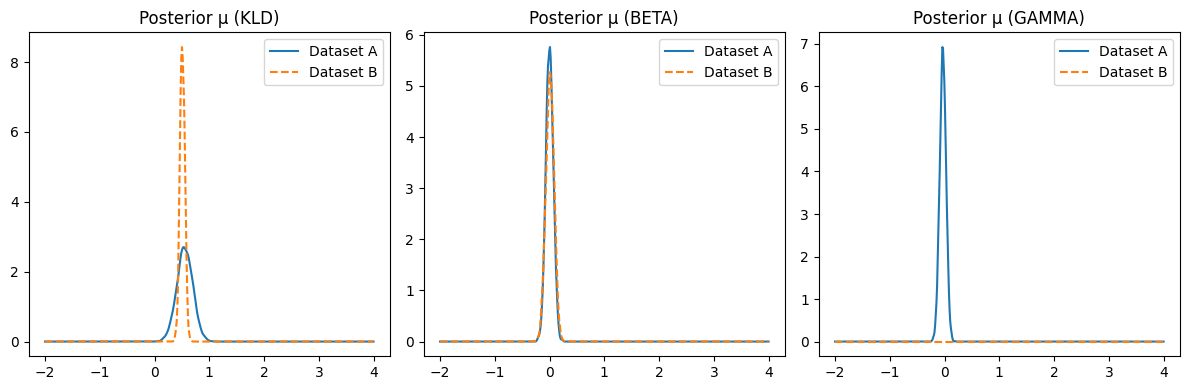

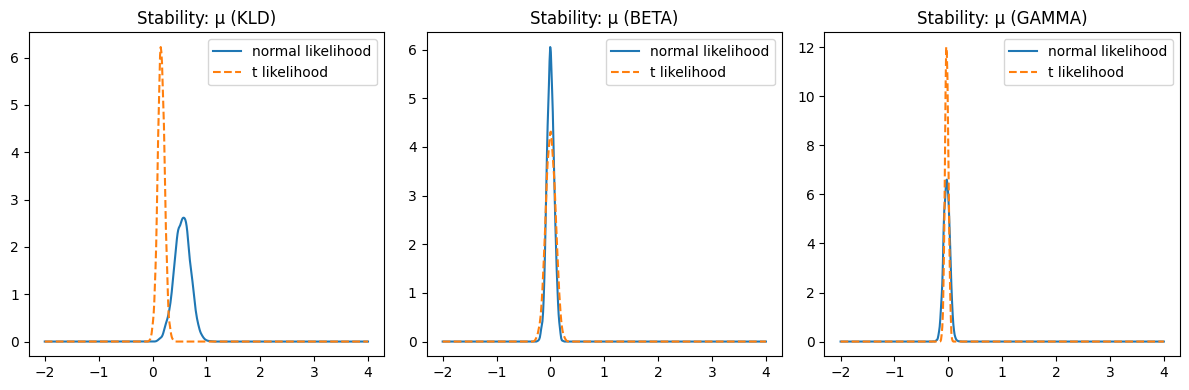

In [21]:
import numpy as np
import scipy.stats as st
import scipy.optimize as opt
from scipy.special import logsumexp
from typing import Tuple, Dict, Callable
import matplotlib.pyplot as plt


rng = np.random.default_rng(0)
def plot_posterior_overlap(yA, yB, mu_draws, methods=["kld","beta","gamma"], like="normal"):
    plt.figure(figsize=(12,4))
    xs = np.linspace(-2, 4, 500)
    for i,method in enumerate(methods):
        samplesA = mu_draws(yA, method=method, like=like)
        samplesB = mu_draws(yB, method=method, like=like)
        kdeA = st.gaussian_kde(samplesA)
        kdeB = st.gaussian_kde(samplesB)
        plt.subplot(1,len(methods),i+1)
        plt.plot(xs, kdeA(xs), label="Dataset A")
        plt.plot(xs, kdeB(xs), label="Dataset B", linestyle="--")
        plt.title(f"Posterior μ ({method.upper()})")
        plt.legend()
    plt.tight_layout()
    plt.show()

def plot_posterior_stability(y, mu_draws, methods=["kld","beta","gamma"], likes=("normal","t")):
    plt.figure(figsize=(12,4))
    xs = np.linspace(-2, 4, 500)
    for i,method in enumerate(methods):
        samples_normal = mu_draws(y, method=method, like=likes[0])
        samples_t = mu_draws(y, method=method, like=likes[1])
        kdeN = st.gaussian_kde(samples_normal)
        kdeT = st.gaussian_kde(samples_t)
        plt.subplot(1,len(methods),i+1)
        plt.plot(xs, kdeN(xs), label=f"{likes[0]} likelihood")
        plt.plot(xs, kdeT(xs), label=f"{likes[1]} likelihood", linestyle="--")
        plt.title(f"Stability: μ ({method.upper()})")
        plt.legend()
    plt.tight_layout()
    plt.show()

# --------------------------
# 0) Helpers: prior & scoring
# --------------------------
def log_ig(sig2, a0, b0):
    return st.invgamma(a=a0, scale=b0).logpdf(sig2)

def log_prior_mu_sig2(mu, sig2, mu0=0.0, v0=10.0, a0=0.01, b0=0.01):
    return st.norm.logpdf(mu, loc=mu0, scale=np.sqrt(v0*sig2)) + log_ig(sig2, a0, b0)

def crps_from_samples(y_test, pred_draws):
    """
    CRPS via unbiased Monte Carlo approximation:
      CRPS(F,y) = E|X - y| - 0.5 E|X - X'|
    pred_draws: shape [S, len(y_test)] predictive samples or S-by-grid density sampling.
    """
    y_test = np.asarray(y_test)
    S = pred_draws.shape[0]
    term1 = np.mean(np.abs(pred_draws - y_test[None, :]), axis=0)
    # sample two independent sets by shuffling
    A = pred_draws
    B = pred_draws[rng.permutation(S)]
    term2 = 0.5 * np.mean(np.abs(A - B), axis=0)
    return float(np.mean(term1 - term2))

def ks_between_predictives(draws1, draws2):
    """
    KS distance between two sets of predictive draws (same test points).
    Flattens both and computes 1-sample KS vs empirical CDF of the other (symmetrized).
    """
    x1 = np.sort(draws1.ravel())
    x2 = np.sort(draws2.ravel())
    # Empirical CDFs at pooled points
    z = np.sort(np.concatenate([x1, x2]))
    F1 = np.searchsorted(x1, z, side="right") / len(x1)
    F2 = np.searchsorted(x2, z, side="right") / len(x2)
    return float(np.max(np.abs(F1 - F2)))


# --------------------------------
# 1) Likelihoods and divergences
# --------------------------------
def normal_pdf(y, mu, sig2):
    return st.norm.pdf(y, loc=mu, scale=np.sqrt(sig2))

def t_pdf(y, mu, sig2, nu=7):
    s = np.sqrt(sig2)
    return st.t.pdf((y - mu)/s, df=nu) / s

# β-divergence loss for Gaussian & Student-t
def beta_loss_normal(y, mu, sig2, beta):
    """
    Density-power divergence loss (β > 1 recommended for robustness).
    For N(mu, s2), ∫ f^β = (2π s2)^(-(β-1)/2) * β^(-1/2).
    """
    s2 = sig2
    fy = normal_pdf(y, mu, s2)
    term1 = -(fy**(beta-1))/(beta-1)
    integral = (2*np.pi*s2)**(-(beta-1)/2) * (beta)**(-0.5)
    term2 = integral / beta
    return np.sum(term1 + term2)

def beta_loss_student(y, mu, sig2, beta, nu=7):
    s = np.sqrt(sig2)
    fy = t_pdf(y, mu, sig2, nu=nu)
    term1 = -(fy**(beta-1))/(beta-1)
    # numeric integral of f^β
    z = np.linspace(mu-10*s, mu+10*s, 4000)
    fz = t_pdf(z, mu, sig2, nu=nu)
    integral = np.trapezoid(fz**beta, z)
    term2 = integral / beta
    return np.sum(term1 + term2)

# γ-likelihood objective (Fujisawa–Eguchi style)
def log_I_normal(mu, sig2, gamma):
    # ∫ f^(1+γ) for normal
    return -(gamma/2.0)*np.log(2*np.pi*sig2) - 0.5*np.log(1.0+gamma)

def log_I_student(mu, sig2, gamma, nu=7):
    s = np.sqrt(sig2)
    z = np.linspace(mu-10*s, mu+10*s, 6000)
    fz = t_pdf(z, mu, sig2, nu=nu)
    val = np.trapezoid(fz**(1.0+gamma), z)
    return np.log(max(val, 1e-300))

# --------------------------------
# 2) Objective functions (KLD, β, γ)
# --------------------------------
def neglogpost_kld(theta, y, like="normal", nu=7, prior_kwargs=None):
    mu, log_sig2 = theta
    sig2 = np.exp(log_sig2)
    if like == "normal":
        ll = np.sum(st.norm.logpdf(y, loc=mu, scale=np.sqrt(sig2)))
    elif like == "t":
        ll = np.sum(np.log(t_pdf(y, mu, sig2, nu=nu) + 1e-300))
    else:
        raise ValueError("like must be 'normal' or 't'")
    lp = log_prior_mu_sig2(mu, sig2, **(prior_kwargs or {}))
    return -(ll + lp)

def neglogpost_beta(theta, y, like="normal", beta=1.8, nu=7, prior_kwargs=None):
    mu, log_sig2 = theta
    sig2 = np.exp(log_sig2)
    if like == "normal":
        loss = beta_loss_normal(y, mu, sig2, beta)
    elif like == "t":
        loss = beta_loss_student(y, mu, sig2, beta, nu=nu)
    else:
        raise ValueError("like must be 'normal' or 't'")
    lp = log_prior_mu_sig2(mu, sig2, **(prior_kwargs or {}))
    return loss - lp

def neglogpost_gamma(theta, y, like="normal", gamma=0.9, nu=7, prior_kwargs=None):
    mu, log_sig2 = theta
    sig2 = np.exp(log_sig2)
    n = len(y)
    if like == "normal":
        fi_log = st.norm.logpdf(y, loc=mu, scale=np.sqrt(sig2))
        log_mean_fgamma = logsumexp(gamma * fi_log) - np.log(n)
        logI = log_I_normal(mu, sig2, gamma)
    elif like == "t":
        fi_log = np.log(t_pdf(y, mu, sig2, nu=nu) + 1e-300)
        log_mean_fgamma = logsumexp(gamma * fi_log) - np.log(n)
        logI = log_I_student(mu, sig2, gamma, nu=nu)
    else:
        raise ValueError("like must be 'normal' or 't'")
    loss = - (1.0/gamma) * log_mean_fgamma + (1.0/(1.0+gamma)) * logI
    lp = log_prior_mu_sig2(mu, sig2, **(prior_kwargs or {}))
    return n*loss - lp

# --------------------------------
# 3) Fit via Laplace (MAP + Hessian)
# --------------------------------
def laplace_fit(y, obj_fun: Callable, x0=None):
    if x0 is None:
        mu0 = float(np.mean(y))
        sig20 = float(np.var(y, ddof=1) if np.var(y, ddof=1) > 1e-6 else 1.0)
        x0 = np.array([mu0, np.log(sig20)])
    res = opt.minimize(obj_fun, x0, method="BFGS")
    th_map = res.x
    cov = res.hess_inv
    return th_map, cov, res

def sample_params(th_map, cov, n_samps=4000):
    return rng.multivariate_normal(th_map, cov, size=n_samps)

def predictive_draws(zgrid, th_samps, like="normal", nu=7, n_per=1):
    """
    Monte Carlo predictive draws at each z in zgrid.
    Returns shape [S, len(zgrid)], where S = len(th_samps)*n_per
    """
    S = len(th_samps) * n_per
    out = np.zeros((S, len(zgrid)))
    idx = 0
    for (mu, log_sig2) in th_samps:
        sig2 = np.exp(log_sig2)
        if like == "normal":
            # Draw one y per z by adding noise; or return density-based draws uniformly (here: random draws)
            for _ in range(n_per):
                out[idx, :] = rng.normal(mu, np.sqrt(sig2), size=len(zgrid))
                idx += 1
        else:
            for _ in range(n_per):
                out[idx, :] = mu + np.sqrt(sig2) * rng.standard_t(df=nu, size=len(zgrid))
                idx += 1
    return out

# --------------------------------
# 4) Reproducibility (overlap criterion)
# --------------------------------
def credible_interval(samples, alpha=0.05):
    lo = np.quantile(samples, alpha/2)
    hi = np.quantile(samples, 1 - alpha/2)
    return lo, hi

def intervals_overlap(intA, intB):
    a1, a2 = intA; b1, b2 = intB
    return (max(a1, b1) <= min(a2, b2))

def estimate_overlap_probability(fit_fun, data_sampler, B=200, alpha=0.05):
    """
    Bootstrap estimate of P[ A_X ∩ B_Y ] >= (1-α)^2.
    fit_fun: returns posterior samples of the functional (e.g., mu)
    data_sampler: function that returns an independent dataset each call
    """
    count_overlap = 0
    for _ in range(B):
        yX = data_sampler()
        yY = data_sampler()
        sX = fit_fun(yX)  # e.g., draws of mu
        sY = fit_fun(yY)
        AX = credible_interval(sX, alpha=alpha)
        BY = credible_interval(sY, alpha=alpha)
        if intervals_overlap(AX, BY):
            count_overlap += 1
    return count_overlap / B

# --------------------------------
# 5) Stability (predictive drift between nearby models)
# --------------------------------
def predictive_drift(fit_pred_A, fit_pred_B, zgrid, S=2000):
    """
    KS distance between predictive draws under two nearby likelihoods.
    fit_pred_*: functions that return predictive draws shape [S, len(zgrid)]
    """
    dA = fit_pred_A(zgrid, S)
    dB = fit_pred_B(zgrid, S)
    return ks_between_predictives(dA, dB)

# --------------------------------
# 6) Wrappers for the three methods
# --------------------------------
def make_fitters(prior_kwargs=None, beta=1.3, gamma=1.0, nu=7):
    """
    Returns dictionaries of functions:
      - param_draws[method, like]: y -> samples of (mu, log_sig2)
      - mu_draws[method, like]: y -> samples of mu
      - predictive[method, like]: (zgrid, S) -> predictive draws shape [S, len(zgrid)]
    """
    def fit_y(y, method, like):
        if method == "kld":
            obj = lambda th: neglogpost_kld(th, y, like=like, nu=nu, prior_kwargs=prior_kwargs)
        elif method == "beta":
            obj = lambda th: neglogpost_beta(th, y, like=like, beta=beta, nu=nu, prior_kwargs=prior_kwargs)
        elif method == "gamma":
            obj = lambda th: neglogpost_gamma(th, y, like=like, gamma=gamma, nu=nu, prior_kwargs=prior_kwargs)
        else:
            raise ValueError("method must be kld|beta|gamma")
        th_map, cov, _ = laplace_fit(y, obj)
        th_samps = sample_params(th_map, cov, n_samps=4000)
        return th_samps

    def mu_draws(y, method="kld", like="normal"):
        th = fit_y(y, method, like)
        return th[:,0]  # mu component

    def predictive_drawer(y, method="kld", like="normal"):
        th = fit_y(y, method, like)
        def _pred(zgrid, S=2000):
            idx = rng.choice(len(th), size=S, replace=True)
            return predictive_draws(zgrid, th[idx], like=like, nu=nu, n_per=1)
        return _pred

    return mu_draws, predictive_drawer

# --------------------------------
# 7) Example usage / experiment harness
# --------------------------------
if __name__ == "__main__":
    # (A) Choose priors (same for all methods)
    prior = dict(mu0=0.0, v0=10.0, a0=0.01, b0=0.01)

    # (B) Make two independent datasets (replace with your real ones)
    n = 500
    def sampler_clean():
        return rng.normal(0.0, 1.0, size=n)
    # Optional contamination for stress
    def sampler_contam(eps=0.1):
        z = rng.random(n) < (1.0 - eps)
        y = np.empty(n)
        y[z]  = rng.normal(0.0, 1.0, size=z.sum())
        y[~z] = rng.normal(6.0, 3.0, size=(~z).sum())
        return y

    yA = sampler_contam(0.1)
    yB = sampler_contam(0.1)

    # (C) Build fitters
    mu_draws, predictive_drawer = make_fitters(prior_kwargs=prior, beta=1.3, gamma=1.0, nu=7)

    # ----- Reproducibility (overlap criterion) -----
    def fitfun_mu(method, like):
        return lambda y: mu_draws(y, method=method, like=like)

    # Estimate P[ overlap ] for each method under the same data-generating sampler
    for method in ["kld", "beta", "gamma"]:
        p_overlap = estimate_overlap_probability(
            fit_fun=fitfun_mu(method, like="normal"),
            data_sampler=lambda: sampler_contam(0.1),
            B=200, alpha=0.05
        )
        print(f"[Reproducibility] {method.upper()} overlap prob ~ {p_overlap:.3f} (target ≥ {(1-0.05)**2:.3f})")

    # ----- Stability (predictive drift under nearby models) -----
    zgrid = np.linspace(-10, 12, 600)

    for method in ["kld", "beta", "gamma"]:
        # Same data, two nearby likelihoods: Normal vs Student-t_7
        pred_normal = predictive_drawer(yA, method=method, like="normal")
        pred_t7     = predictive_drawer(yA, method=method, like="t")
        drift = predictive_drift(pred_normal, pred_t7, zgrid, S=2000)
        print(f"[Stability] {method.upper()} KS drift (Normal ↔ t7): {drift:.3f}")

    # ----- Predictive quality (optional, needs a test set) -----
    # Build predictive draws and compute CRPS on held-out test data
    y_test = sampler_contam(0.1)
    for method in ["kld", "beta", "gamma"]:
        pred = predictive_drawer(yA, method=method, like="normal")
        draws = pred(zgrid=np.arange(len(y_test)), S=2000)  # here we just draw samples; replace with pointwise predictive if desired
        # For CRPS, use draws of y_test (we’re drawing directly y~predictive for each test index)
        # The simple hack above uses index grid; for a location model, any iid draw is fine.
        crps = crps_from_samples(y_test, draws)
        print(f"[Predictive] {method.upper()} CRPS (lower is better): {crps:.4f}")

    # Visualize reproducibility: two independent datasets
plot_posterior_overlap(yA, yB, mu_draws, methods=["kld","beta","gamma"], like="normal")

# Visualize stability: one dataset, two nearby likelihoods
plot_posterior_stability(yA, mu_draws, methods=["kld","beta","gamma"], likes=("normal","t"))



[Reproducibility] DGP_NAME =cauchy | KLD overlap ≈ 0.565 (target ≥ 0.902)
[Reproducibility] DGP_NAME =cauchy | BETA overlap ≈ 1.000 (target ≥ 0.902)
[Reproducibility] DGP_NAME =cauchy | GAMMA overlap ≈ 0.945 (target ≥ 0.902)
[Posterior Stability] cauchy | KLD KS drift (Normal↔t7): 1.000


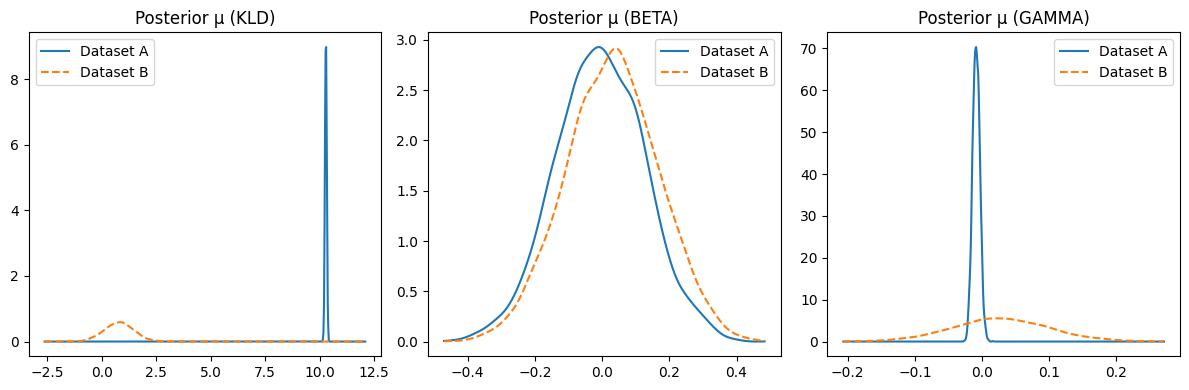

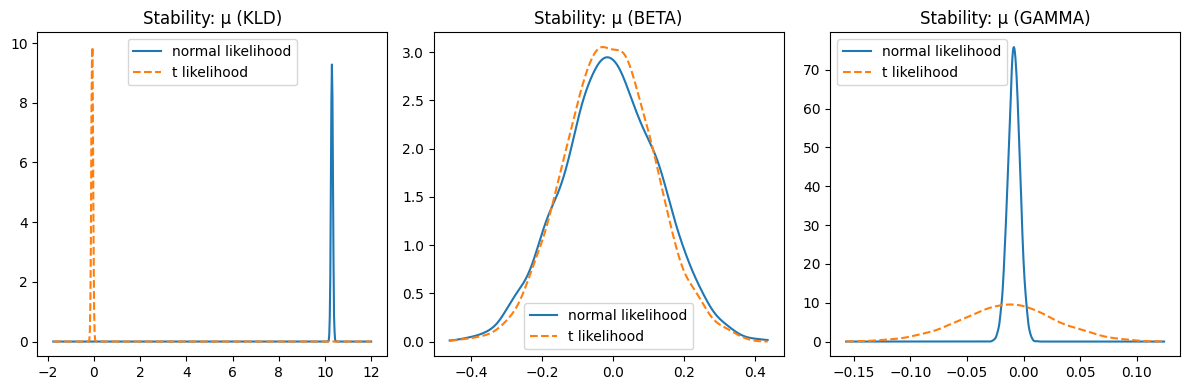

[Predictive]     cauchy | KLD CRPS: 48.6107
[Predictive]     cauchy | BETA CRPS: 3.4711
[Predictive]     cauchy | GAMMA CRPS: 3.5034
[Posterior Stability] cauchy | BETA KS drift (Normal↔t7): 0.025


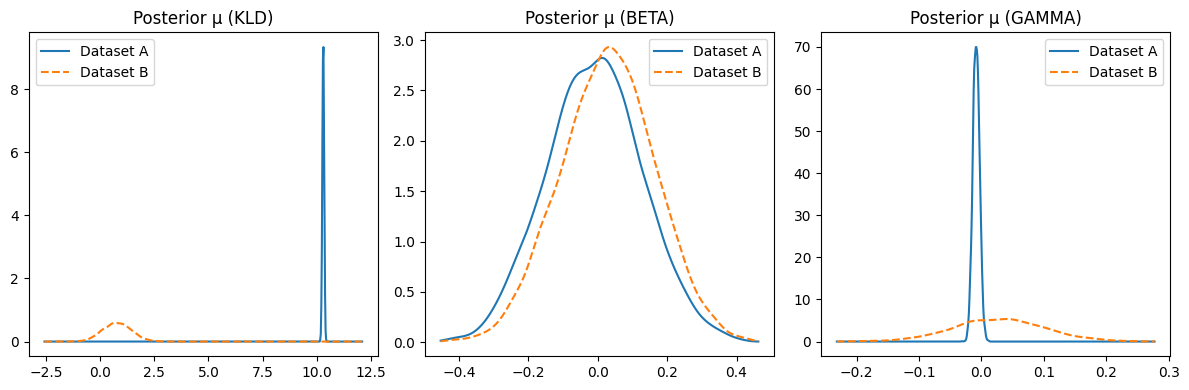

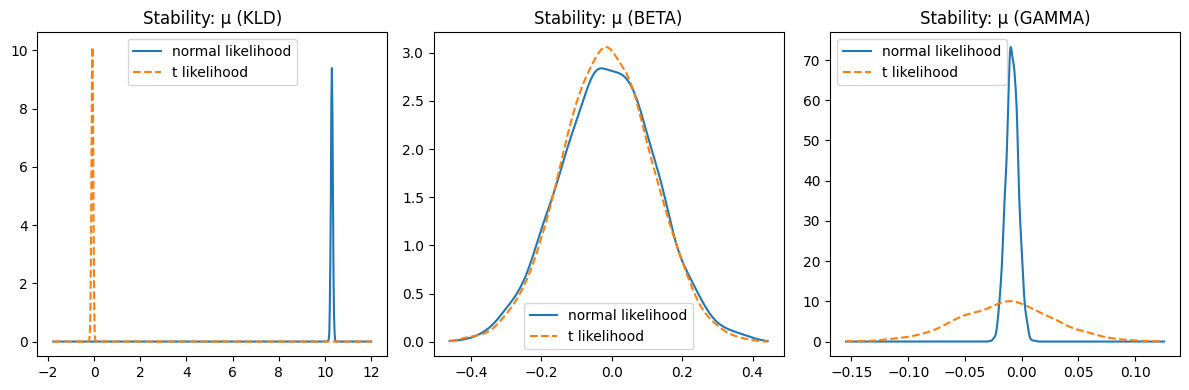

[Predictive]     cauchy | KLD CRPS: 48.4650
[Predictive]     cauchy | BETA CRPS: 3.4712
[Predictive]     cauchy | GAMMA CRPS: 3.5020
[Posterior Stability] cauchy | GAMMA KS drift (Normal↔t7): 0.432


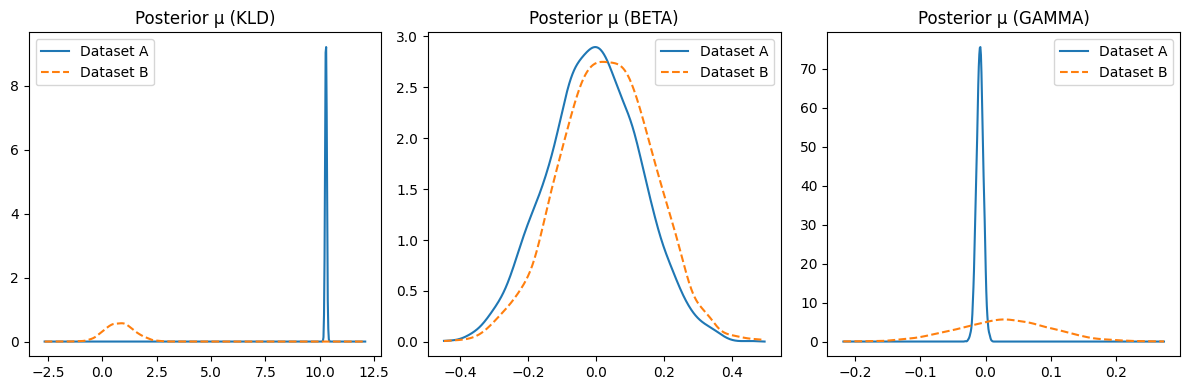

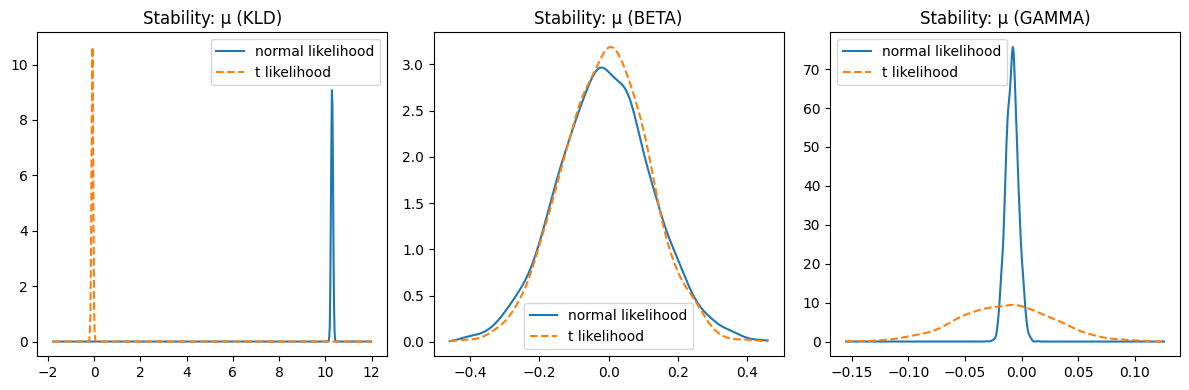

[Predictive]     cauchy | KLD CRPS: 48.3310
[Predictive]     cauchy | BETA CRPS: 3.4699
[Predictive]     cauchy | GAMMA CRPS: 3.5033


In [24]:
import numpy as np
import scipy.stats as st
import scipy.optimize as opt
from scipy.special import logsumexp
from typing import Callable
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)

# --------------------------
# Plot helpers
# --------------------------
def _auto_xs(samplesA, samplesB=None, pad=0.15, num=600):
    if samplesB is None:
        q1, q2 = np.quantile(samplesA, [0.005, 0.995])
    else:
        q1a, q2a = np.quantile(samplesA, [0.005, 0.995])
        q1b, q2b = np.quantile(samplesB, [0.005, 0.995])
        q1, q2 = min(q1a, q1b), max(q2a, q2b)
    width = max(q2 - q1, 1e-6)
    lo = q1 - pad*width
    hi = q2 + pad*width
    return np.linspace(lo, hi, num)

def plot_posterior_overlap(yA, yB, mu_draws, methods=("kld","beta","gamma"), like="normal"):
    plt.figure(figsize=(12,4))
    for i,method in enumerate(methods):
        sA = mu_draws(yA, method=method, like=like)
        sB = mu_draws(yB, method=method, like=like)
        xs = _auto_xs(sA, sB)
        kdeA = st.gaussian_kde(sA); kdeB = st.gaussian_kde(sB)
        plt.subplot(1,len(methods),i+1)
        plt.plot(xs, kdeA(xs), label="Dataset A")
        plt.plot(xs, kdeB(xs), label="Dataset B", linestyle="--")
        plt.title(f"Posterior μ ({method.upper()})"); plt.legend()
    plt.tight_layout(); plt.show()

def plot_posterior_stability(y, mu_draws, methods=("kld","beta","gamma"), likes=("normal","t")):
    plt.figure(figsize=(12,4))
    for i,method in enumerate(methods):
        sN = mu_draws(y, method=method, like=likes[0])
        sT = mu_draws(y, method=method, like=likes[1])
        xs = _auto_xs(sN, sT)
        kdeN = st.gaussian_kde(sN); kdeT = st.gaussian_kde(sT)
        plt.subplot(1,len(methods),i+1)
        plt.plot(xs, kdeN(xs), label=f"{likes[0]} likelihood")
        plt.plot(xs, kdeT(xs), label=f"{likes[1]} likelihood", linestyle="--")
        plt.title(f"Stability: μ ({method.upper()})"); plt.legend()
    plt.tight_layout(); plt.show()

# --------------------------
# Prior & scoring
# --------------------------
def log_ig(sig2, a0, b0):
    return st.invgamma(a=a0, scale=b0).logpdf(sig2)

def log_prior_mu_sig2(mu, sig2, mu0=0.0, v0=10.0, a0=0.01, b0=0.01):
    return st.norm.logpdf(mu, loc=mu0, scale=np.sqrt(v0*sig2)) + log_ig(sig2, a0, b0)

def crps_from_samples(y_test, pred_draws):
    y_test = np.asarray(y_test)
    S = pred_draws.shape[0]
    term1 = np.mean(np.abs(pred_draws - y_test[None, :]), axis=0)
    A = pred_draws; B = pred_draws[rng.permutation(S)]
    term2 = 0.5 * np.mean(np.abs(A - B), axis=0)
    return float(np.mean(term1 - term2))

def ks_between_predictives(draws1, draws2):
    x1 = np.sort(draws1.ravel()); x2 = np.sort(draws2.ravel())
    z = np.sort(np.concatenate([x1, x2]))
    F1 = np.searchsorted(x1, z, side="right") / len(x1)
    F2 = np.searchsorted(x2, z, side="right") / len(x2)
    return float(np.max(np.abs(F1 - F2)))

# --------------------------
# Likelihood bits
# --------------------------
def normal_pdf(y, mu, sig2):
    return st.norm.pdf(y, loc=mu, scale=np.sqrt(sig2))

def t_pdf(y, mu, sig2, nu=7):
    s = np.sqrt(sig2)
    return st.t.pdf((y - mu)/s, df=nu) / s

# β-divergence pieces
def beta_loss_normal(y, mu, sig2, beta):
    s2 = sig2
    fy = normal_pdf(y, mu, s2)
    term1 = -(fy**(beta-1))/(beta-1)
    integral = (2*np.pi*s2)**(-(beta-1)/2) * (beta)**(-0.5)
    term2 = integral / beta
    return np.sum(term1 + term2)

def beta_loss_student(y, mu, sig2, beta, nu=7):
    s = np.sqrt(sig2)
    fy = t_pdf(y, mu, sig2, nu=nu)
    term1 = -(fy**(beta-1))/(beta-1)
    z = np.linspace(mu-10*s, mu+10*s, 4000)
    fz = t_pdf(z, mu, sig2, nu=nu)
    integral = np.trapezoid(fz**beta, z)
    term2 = integral / beta
    return np.sum(term1 + term2)

# γ-likelihood pieces
def log_I_normal(mu, sig2, gamma):
    return -(gamma/2.0)*np.log(2*np.pi*sig2) - 0.5*np.log(1.0+gamma)

def log_I_student(mu, sig2, gamma, nu=7):
    s = np.sqrt(sig2)
    z = np.linspace(mu-10*s, mu+10*s, 6000)
    fz = t_pdf(z, mu, sig2, nu=nu)
    val = np.trapezoid(fz**(1.0+gamma), z)
    return np.log(max(val, 1e-300))

# --------------------------
# Objectives (KLD, β, γ)
# --------------------------
def neglogpost_kld(theta, y, like="normal", nu=7, prior_kwargs=None):
    mu, log_sig2 = theta; sig2 = np.exp(log_sig2)
    if like == "normal":
        ll = np.sum(st.norm.logpdf(y, loc=mu, scale=np.sqrt(sig2)))
    elif like == "t":
        ll = np.sum(np.log(t_pdf(y, mu, sig2, nu=nu) + 1e-300))
    else:
        raise ValueError("like must be 'normal' or 't'")
    lp = log_prior_mu_sig2(mu, sig2, **(prior_kwargs or {}))
    return -(ll + lp)

def neglogpost_beta(theta, y, like="normal", beta=1.6, nu=7, prior_kwargs=None):
    mu, log_sig2 = theta; sig2 = np.exp(log_sig2)
    if like == "normal":
        loss = beta_loss_normal(y, mu, sig2, beta)
    elif like == "t":
        loss = beta_loss_student(y, mu, sig2, beta, nu=nu)
    else:
        raise ValueError("like must be 'normal' or 't'")
    lp = log_prior_mu_sig2(mu, sig2, **(prior_kwargs or {}))
    return loss - lp

def neglogpost_gamma(theta, y, like="normal", gamma=0.9, nu=7, prior_kwargs=None):
    mu, log_sig2 = theta; sig2 = np.exp(log_sig2); n = len(y)
    if like == "normal":
        fi_log = st.norm.logpdf(y, loc=mu, scale=np.sqrt(sig2))
        log_mean_fgamma = logsumexp(gamma * fi_log) - np.log(n)
        logI = log_I_normal(mu, sig2, gamma)
    elif like == "t":
        fi_log = np.log(t_pdf(y, mu, sig2, nu=nu) + 1e-300)
        log_mean_fgamma = logsumexp(gamma * fi_log) - np.log(n)
        logI = log_I_student(mu, sig2, gamma, nu=nu)
    else:
        raise ValueError("like must be 'normal' or 't'")
    loss = - (1.0/gamma) * log_mean_fgamma + (1.0/(1.0+gamma)) * logI
    lp = log_prior_mu_sig2(mu, sig2, **(prior_kwargs or {}))
    return n*loss - lp

# --------------------------
# Laplace + predictive draws
# --------------------------
def laplace_fit(y, obj_fun: Callable, x0=None):
    if x0 is None:
        mu0 = float(np.mean(y))
        sig20 = float(np.var(y, ddof=1) if np.var(y, ddof=1) > 1e-6 else 1.0)
        x0 = np.array([mu0, np.log(sig20)])
    res = opt.minimize(obj_fun, x0, method="BFGS")
    th_map = res.x; cov = res.hess_inv
    return th_map, cov, res

def sample_params(th_map, cov, n_samps=4000):
    return rng.multivariate_normal(th_map, cov, size=n_samps)

def predictive_draws(zgrid, th_samps, like="normal", nu=7, n_per=1):
    S = len(th_samps) * n_per
    out = np.zeros((S, len(zgrid))); idx = 0
    for (mu, log_sig2) in th_samps:
        sig2 = np.exp(log_sig2)
        if like == "normal":
            for _ in range(n_per):
                out[idx, :] = rng.normal(mu, np.sqrt(sig2), size=len(zgrid)); idx += 1
        else:
            for _ in range(n_per):
                out[idx, :] = mu + np.sqrt(sig2) * rng.standard_t(df=nu, size=len(zgrid)); idx += 1
    return out

# --------------------------
# Reproducibility & stability metrics
# --------------------------
def credible_interval(samples, alpha=0.05):
    lo = np.quantile(samples, alpha/2); hi = np.quantile(samples, 1 - alpha/2)
    return lo, hi

def intervals_overlap(intA, intB):
    a1, a2 = intA; b1, b2 = intB
    return (max(a1, b1) <= min(a2, b2))

def estimate_overlap_probability(fit_fun, data_sampler, B=200, alpha=0.05):
    count_overlap = 0
    for _ in range(B):
        yX = data_sampler(); yY = data_sampler()
        sX = fit_fun(yX); sY = fit_fun(yY)
        AX = credible_interval(sX, alpha=alpha); BY = credible_interval(sY, alpha=alpha)
        if intervals_overlap(AX, BY): count_overlap += 1
    return count_overlap / B

def predictive_drift(fit_pred_A, fit_pred_B, zgrid, S=2000):
    dA = fit_pred_A(zgrid, S); dB = fit_pred_B(zgrid, S)
    return ks_between_predictives(dA, dB)

# --------------------------
# Fitters
# --------------------------
def make_fitters(prior_kwargs=None, beta=1.6, gamma=0.9, nu=7):
    def fit_y(y, method, like):
        if method == "kld":
            obj = lambda th: neglogpost_kld(th, y, like=like, nu=nu, prior_kwargs=prior_kwargs)
        elif method == "beta":
            obj = lambda th: neglogpost_beta(th, y, like=like, beta=beta, nu=nu, prior_kwargs=prior_kwargs)
        elif method == "gamma":
            obj = lambda th: neglogpost_gamma(th, y, like=like, gamma=gamma, nu=nu, prior_kwargs=prior_kwargs)
        else:
            raise ValueError("method must be kld|beta|gamma")
        th_map, cov, _ = laplace_fit(y, obj)
        th_samps = sample_params(th_map, cov, n_samps=4000)
        return th_samps

    def mu_draws(y, method="kld", like="normal"):
        th = fit_y(y, method, like); return th[:,0]

    def predictive_drawer(y, method="kld", like="normal"):
        th = fit_y(y, method, like)
        def _pred(zgrid, S=2000):
            idx = rng.choice(len(th), size=S, replace=True)
            return predictive_draws(zgrid, th[idx], like=like, nu=nu, n_per=1)
        return _pred
    return mu_draws, predictive_drawer

# --------------------------
#  TRUE DGPs
# --------------------------
def sampler_cauchy(n):                 # infinite variance
    return st.cauchy.rvs(loc=0.0, scale=1.0, size=n, random_state=None)

def sampler_skew_contam(n, eps=0.15, shift=6.0, scale=2.0):
    z = rng.random(n) < (1.0 - eps)
    y = np.empty(n)
    y[z]  = rng.normal(0.0, 1.0, size=z.sum())
    y[~z] = rng.normal(shift, scale, size=(~z).sum())
    return y

def sampler_varmix(n, eps=0.2):
    z = rng.random(n) < (1.0 - eps)
    y = np.empty(n)
    y[z]  = rng.normal(0.0, 1.0, size=z.sum())
    y[~z] = rng.normal(0.0, 6.0, size=(~z).sum()) # same mean, huge variance
    return y

def sampler_tri_modal(n):
    comps = rng.choice([0,1,2], size=n, p=[0.6, 0.2, 0.2])
    y = np.empty(n)
    y[comps==0] = rng.normal(0.0, 1.0, np.sum(comps==0))
    y[comps==1] = rng.normal(-5.0, 1.5, np.sum(comps==1))
    y[comps==2] = rng.normal(+5.0, 1.5, np.sum(comps==2))
    return y

def sampler_drift(n, delta=2.5):       # nonstationary mean
    y = np.empty(n); n1 = n//2
    y[:n1] = rng.normal(0.0, 1.0, n1)
    y[n1:] = rng.normal(delta, 1.0, n - n1)
    rng.shuffle(y); return y

from scipy.stats import ks_2samp, wasserstein_distance

def posterior_stability(mu_samples1, mu_samples2, metric="ks"):
    if metric == "ks":
        stat, _ = ks_2samp(mu_samples1, mu_samples2)
        return stat
    elif metric == "wasserstein":
        return wasserstein_distance(mu_samples1, mu_samples2)
    elif metric == "ci_overlap":
        ci1 = credible_interval(mu_samples1)
        ci2 = credible_interval(mu_samples2)
        return intervals_overlap(ci1, ci2)  # True/False
    else:
        raise ValueError("Unknown metric")

# --------------------------
# Main
# --------------------------
if __name__ == "__main__":
    # Prior (weakly informative; same for all methods)
    prior = dict(mu0=0.0, v0=10.0, a0=0.01, b0=0.01)

    # >>> Choose a TRUE DGP here <<<
    DGP_NAME = "cauchy"   # options: cauchy | varmix | skew | tri | drift
    n = 500

    if DGP_NAME == "cauchy":
        data_sampler = lambda: sampler_cauchy(n)
    elif DGP_NAME == "varmix":
        data_sampler = lambda: sampler_varmix(n, eps=0.2)
    elif DGP_NAME == "skew":
        data_sampler = lambda: sampler_skew_contam(n, eps=0.15, shift=6.0, scale=2.0)
    elif DGP_NAME == "tri":
        data_sampler = lambda: sampler_tri_modal(n)
    elif DGP_NAME == "drift":
        data_sampler = lambda: sampler_drift(n, delta=2.5)
    else:
        raise ValueError("Unknown DGP_NAME")

    # Two independent datasets from the (misspecified) truth
    yA = data_sampler(); yB = data_sampler()

    # Fitters (bump robustness a bit for tougher DGPs)
    mu_draws, predictive_drawer = make_fitters(prior_kwargs=prior, beta=1.6, gamma=0.9, nu=7)

    # Reproducibility (overlap criterion on μ)
    def fitfun_mu(method, like): return lambda y: mu_draws(y, method=method, like=like)
    for method in ["kld", "beta", "gamma"]:
        p_overlap = estimate_overlap_probability(
            fit_fun=fitfun_mu(method, like="normal"),
            data_sampler=data_sampler, B=200, alpha=0.05
        )
        print(f"[Reproducibility] {DGP_NAME =:>6s} | {method.upper()} overlap ≈ {p_overlap:.3f} (target ≥ {(1-0.05)**2:.3f})")

# Posterior stability (Normal vs t7 on the same data)
for method in ["kld", "beta", "gamma"]:
    samples_normal = mu_draws(yA, method=method, like="normal")
    samples_t      = mu_draws(yA, method=method, like="t")
    from scipy.stats import ks_2samp
    stat, _ = ks_2samp(samples_normal, samples_t)
    print(f"[Posterior Stability] {DGP_NAME:>6s} | {method.upper()} KS drift (Normal↔t7): {stat:.3f}")

    # Visuals
    plot_posterior_overlap(yA, yB, mu_draws, methods=("kld","beta","gamma"), like="normal")
    plot_posterior_stability(yA, mu_draws, methods=("kld","beta","gamma"), likes=("normal","t"))

    # Optional: predictive accuracy (CRPS) using yB as "test"
    for method in ["kld", "beta", "gamma"]:
        pred = predictive_drawer(yA, method=method, like="normal")
        draws = pred(zgrid=np.arange(len(yB)), S=2000)  # iid draws are fine for location model
        crps = crps_from_samples(yB, draws)
        print(f"[Predictive]     {DGP_NAME:>6s} | {method.upper()} CRPS: {crps:.4f}")


In [1]:
import numpy as np
import scipy.stats as st
import scipy.optimize as opt
from scipy.special import logsumexp
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)

# =========================================================
#  Helpers for Gaussian divergences
# =========================================================
def _sp(A): return 0.5*(A+A.T)

def _logdet_psd(S):
    sign, logdet = np.linalg.slogdet(S)
    if sign <= 0: raise ValueError("Covariance not SPD.")
    return logdet

def kl_gaussians(m, S, m0, S0):
    d = len(m); S0i = np.linalg.inv(S0)
    dm = (m0-m)[:,None]
    return 0.5*(np.trace(S0i@S) + float(dm.T@S0i@dm) - d + _logdet_psd(S0)-_logdet_psd(S))

def beta_div_gaussians(m, S, m0, S0, beta):
    if beta==1.0: return kl_gaussians(m,S,m0,S0)
    d=len(m); Si=np.linalg.inv(S); S0i=np.linalg.inv(S0)
    log_int_qb=-(d*(beta-1)/2)*np.log(2*np.pi)-0.5*(beta-1)*_logdet_psd(S)-0.5*d*np.log(beta)
    int_qb=np.exp(log_int_qb)
    log_int_pb=-(d*(beta-1)/2)*np.log(2*np.pi)-0.5*(beta-1)*_logdet_psd(S0)-0.5*d*np.log(beta)
    int_pb=np.exp(log_int_pb)
    Cp_log=-(d*(beta-1)/2)*np.log(2*np.pi)-0.5*(beta-1)*_logdet_psd(S0)
    Lambda=_sp(Si+(beta-1)*S0i); Lam_i=np.linalg.inv(Lambda)
    mu_star=Lam_i@(Si@m+(beta-1)*S0i@m0)
    quad=m@Si@m+(beta-1)*(m0@S0i@m0)-(mu_star@Lambda@mu_star)
    log_cross=Cp_log-0.5*_logdet_psd(Lambda)-0.5*_logdet_psd(S)-0.5*quad
    cross=np.exp(log_cross)
    return (int_qb+(beta-1)*int_pb-beta*cross)/(beta*(beta-1))

def gamma_div_gaussians(m,S,m0,S0,gamma):
    if gamma==0.0: return kl_gaussians(m,S,m0,S0)
    d=len(m); Si=np.linalg.inv(S); S0i=np.linalg.inv(S0)
    b=1.0+gamma
    log_int_q=-(d*(b-1)/2)*np.log(2*np.pi)-0.5*(b-1)*_logdet_psd(S)-0.5*d*np.log(b)
    int_q=np.exp(log_int_q)
    log_int_p=-(d*(b-1)/2)*np.log(2*np.pi)-0.5*(b-1)*_logdet_psd(S0)-0.5*d*np.log(b)
    int_p=np.exp(log_int_p)
    C_log=-(d*gamma/2)*np.log(2*np.pi)-0.5*gamma*_logdet_psd(S0)
    Lambda=_sp(Si+gamma*S0i); Lam_i=np.linalg.inv(Lambda)
    mu_star=Lam_i@(Si@m+gamma*S0i@m0)
    quad=m@Si@m+gamma*(m0@S0i@m0)-(mu_star@Lambda@mu_star)
    log_cross=C_log-0.5*_logdet_psd(Lambda)-0.5*_logdet_psd(S)-0.5*quad
    cross=np.exp(log_cross)
    return (int_q+gamma*int_p-(1+gamma)*cross)/(gamma*(1+gamma))

# =========================================================
#  Variational q=N(m,S) parametrization
# =========================================================
def chol_from_unconstrained(u):
    a,b,c=u
    L=np.array([[np.exp(a),0.0],[b,np.exp(c)]])
    return L@L.T, L

def pack_params(m,u): return np.concatenate([m,u])
def unpack_params(w): return w[:2], w[2:]

# Gaussian prior for θ=(mu,logσ²)
m_pi=np.array([0.0,0.0]); S_pi=np.diag([10.0,1.0])

# =========================================================
#  Expected losses
# =========================================================
def expected_loss_KLD(y,like,m):
    mu,log_s2=m; sig=np.sqrt(np.exp(log_s2))
    if like=="normal": return -np.sum(st.norm.logpdf(y,loc=mu,scale=sig))
    elif like=="t": return -np.sum(np.log(st.t.pdf((y-mu)/sig,df=7)/sig+1e-300))
    else: raise ValueError

# =========================================================
#  RoT objective
# =========================================================
def make_rot_objective(y,like="normal",method="kld",beta=1.6,gamma=0.9,mc=256):
    def objective(w):
        m,u=unpack_params(w); S,L=chol_from_unconstrained(u)
        if method=="kld":
            loss=expected_loss_KLD(y,like,m)
        else:
            eps=rng.normal(size=(mc,2)); thetas=m[None,:]+eps@L.T
            mu_s=thetas[:,0]; sig_s=np.sqrt(np.exp(thetas[:,1]))
            n=len(y); term=0.0
            if method=="beta":
                for mu_i,s_i in zip(mu_s,sig_s):
                    fy=st.norm.pdf(y,loc=mu_i,scale=s_i)
                    t1=-np.sum((fy**(beta-1))/(beta-1))
                    integral=(2*np.pi*s_i*s_i)**(-(beta-1)/2)*(beta)**(-0.5)
                    t2=n*(integral/beta); term+=t1+t2
                loss=term/mc
            elif method=="gamma":
                for mu_i,s_i in zip(mu_s,sig_s):
                    fi_log=st.norm.logpdf(y,loc=mu_i,scale=s_i)
                    log_mean=logsumexp(gamma*fi_log)-np.log(n)
                    logI=-(gamma/2)*np.log(2*np.pi*s_i*s_i)-0.5*np.log(1+gamma)
                    loss+=n*(-(1/gamma)*log_mean+(1/(1+gamma))*logI)
                loss=loss/mc
            else: raise ValueError
        # divergence
        if method=="kld": div=kl_gaussians(m,S,m_pi,S_pi)
        elif method=="beta": div=beta_div_gaussians(m,S,m_pi,S_pi,beta)
        else: div=gamma_div_gaussians(m,S,m_pi,S_pi,gamma)
        return loss+div
    return objective

def fit_rot(y,like="normal",method="kld",beta=1.6,gamma=0.9,mc=256):
    mu0=float(np.mean(y)); sig20=float(np.var(y,ddof=1) if np.var(y)>1e-6 else 1.0)
    m_init=np.array([mu0,np.log(sig20)]); u_init=np.array([np.log(0.3),0.0,np.log(0.3)])
    f=make_rot_objective(y,like,method,beta,gamma,mc)
    w0=pack_params(m_init,u_init); res=opt.minimize(f,w0,method="L-BFGS-B")
    m_hat,u_hat=unpack_params(res.x); S_hat,_=chol_from_unconstrained(u_hat)
    return m_hat,S_hat,res

def sample_theta_from_q(m,S,n_samps=4000): return rng.multivariate_normal(m,S,size=n_samps)

def make_fitters_rot(beta=1.6,gamma=0.9,nu=7,mc=256):
    def mu_draws(y,method="kld",like="normal"):
        m_hat,S_hat,_=fit_rot(y,like,method,beta,gamma,mc)
        th=sample_theta_from_q(m_hat,S_hat,4000); return th[:,0]
    def predictive_drawer(y,method="kld",like="normal"):
        m_hat,S_hat,_=fit_rot(y,like,method,beta,gamma,mc)
        th=sample_theta_from_q(m_hat,S_hat,4000)
        def _pred(zgrid,S=2000):
            idx=rng.choice(len(th),size=S,replace=True); sel=th[idx]
            out=np.zeros((S,len(zgrid)))
            for i,(mu,log_s2) in enumerate(sel):
                sig=np.sqrt(np.exp(log_s2))
                out[i,:]=rng.normal(mu,sig,len(zgrid))
            return out
        return _pred
    return mu_draws,predictive_drawer

# =========================================================
#  Example DGP + experiment
# =========================================================
def sampler_cauchy(n): return st.cauchy.rvs(loc=0.0,scale=1.0,size=n)

if __name__=="__main__":
    n=500; data_sampler=lambda: sampler_cauchy(n)
    yA=data_sampler(); yB=data_sampler()
    mu_draws,predictive_drawer=make_fitters_rot(beta=1.6,gamma=0.9)

    for method in ["kld","beta","gamma"]:
        mus=mu_draws(yA,method=method,like="normal")
        print(f"{method.upper()} posterior mean≈ {np.mean(mus):.3f}")


/var/folders/wl/l6v7zb5d5hv77sr6wky_w9km0000gn/T/ipykernel_1208/155743568.py:22: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return 0.5*(np.trace(S0i@S) + float(dm.T@S0i@dm) - d + _logdet_psd(S0)-_logdet_psd(S))


KLD posterior mean≈ -1.661
BETA posterior mean≈ -2.467


UnboundLocalError: cannot access local variable 'loss' where it is not associated with a value